In [26]:
import numpy as np
from matplotlib import pyplot as plt

# Part I. Calm Walk: Learning the Panda’s Rhythm

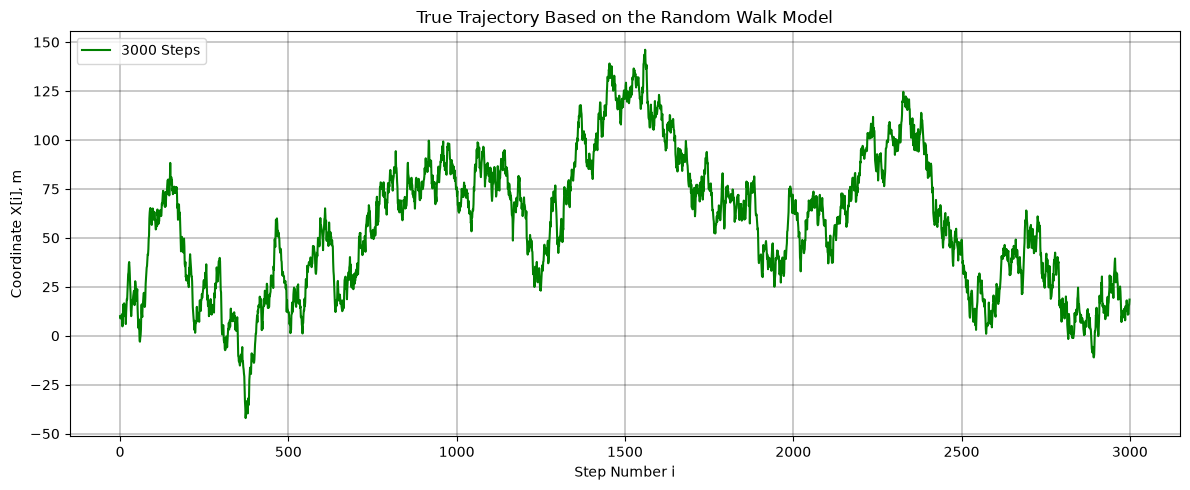

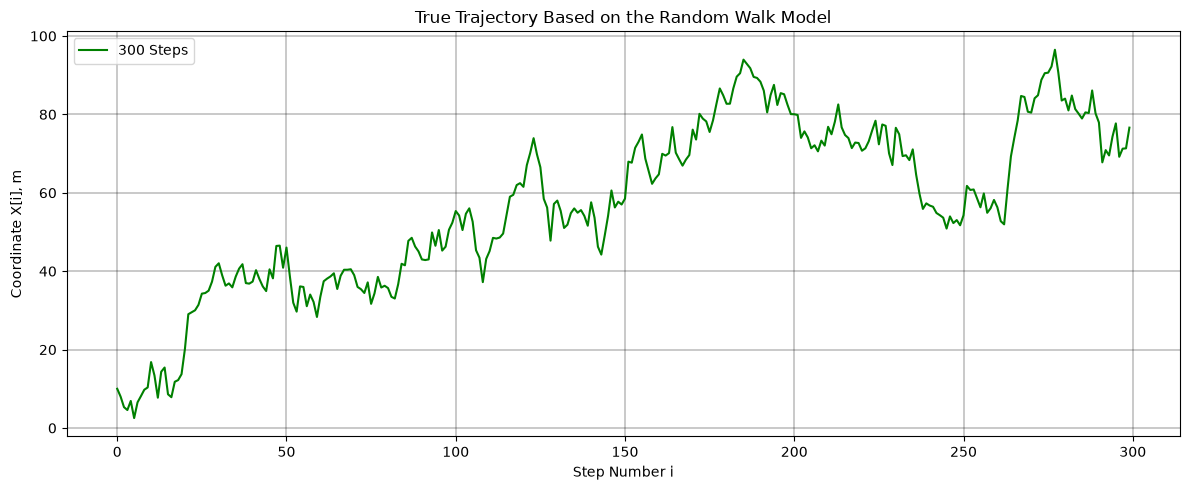

In [27]:
# define the constants for true trajectory
SIGMA_W = np.sqrt(14)
SIZE_MAX = 3000
SIZE_MIN = 300
INITIAL_COORDINATE_M = 10

# generate a true trajectory of a walking panda using the random walk model
def generate_true_trajectory(size, init_coord):
    traj_points = np.zeros(size)
    traj_points[0] = init_coord

    for i in range(1, size):
        process_noise = np.random.normal(
                        loc=0.0,
                        scale=SIGMA_W
                    )
        traj_points[i] = traj_points[i-1] + process_noise

    return traj_points

# store 3000 true trajectory points in the true_trajectory_huge array
true_trajectory_huge = generate_true_trajectory(SIZE_MAX, INITIAL_COORDINATE_M)

# store 300 true trajectory points in the true_trajectory_small array
true_trajectory_small = generate_true_trajectory(SIZE_MIN, INITIAL_COORDINATE_M)

# declare a function to plot the true trajectory 
def plot_true_trajectory(true_traj, title, label):
    steps = np.arange(true_traj.size)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(steps, true_traj, color="green", linewidth=1.5, label=label)
    ax.set_title(title)
    ax.set_xlabel("Step Number i")
    ax.set_ylabel("Coordinate X[i], m")
    ax.grid(True, color="black", linewidth=0.3)
    ax.legend(frameon=True, markerscale=4, ncol=2, loc="upper left")
    fig.tight_layout()
    plt.show()

# call the self-written function above to plot the true trajectories for 3000 and 300 points correspondingly
plot_true_trajectory(true_trajectory_huge, "True Trajectory Based on the Random Walk Model", "3000 Steps")
plot_true_trajectory(true_trajectory_small, "True Trajectory Based on the Random Walk Model", "300 Steps")

In [28]:
# define the constants for noise measured trajectory
SIGMA_ETA = np.sqrt(10)   # standart deviation of noise

# generate a measured trajectory based on true one
def generate_measured_trajectory(true_trajectory):
  measured_trajectory = true_trajectory.copy()
  return measured_trajectory + np.random.normal(0.0, SIGMA_ETA, size=measured_trajectory.size)

measured_trajectory_huge = generate_measured_trajectory(true_trajectory_huge)
measured_trajectory_small = generate_measured_trajectory(true_trajectory_small)

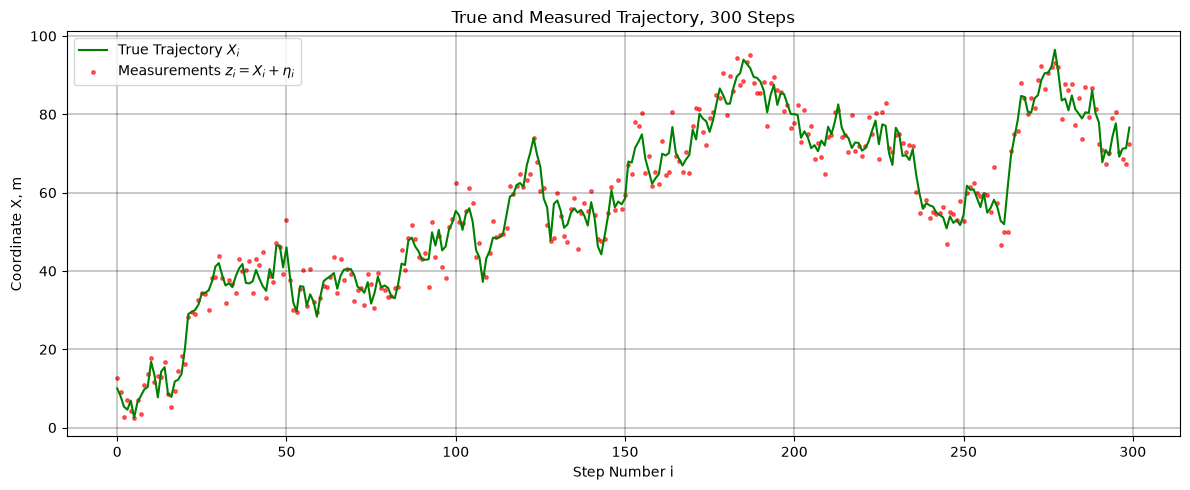

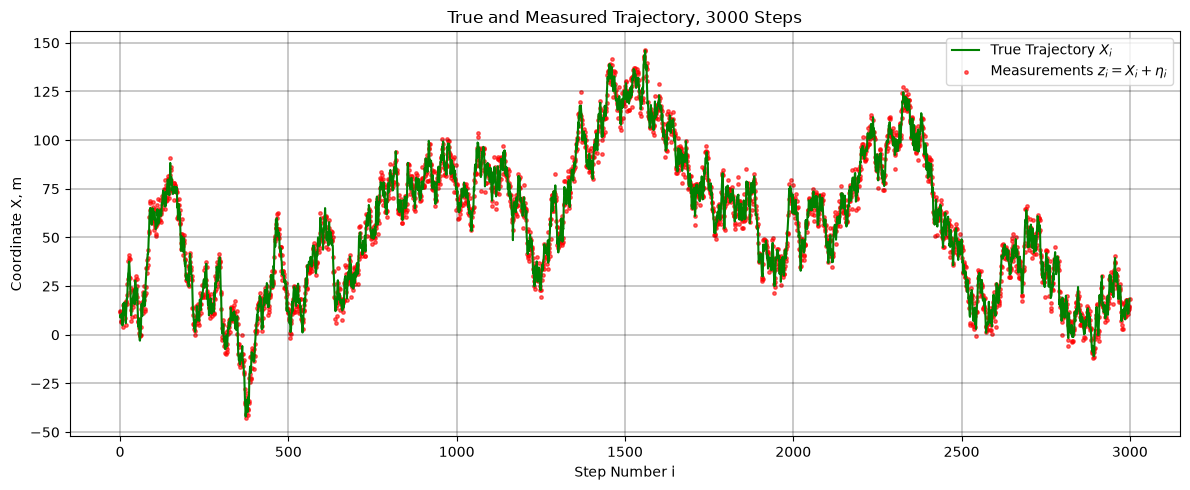

In [31]:
def plot_true_vs_measured(true_traj, measured_traj, title):
    steps = np.arange(true_traj.size)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(steps, true_traj, color="green", linewidth=1.5, label="True Trajectory $X_i$")
    ax.scatter(steps, measured_traj, color="red", s=6, alpha=0.6, label="Measurements $z_i = X_i + \\eta_i$")
    ax.set_title(title)
    ax.set_xlabel("Step Number i")
    ax.set_ylabel("Coordinate X, m")
    ax.grid(True, color="black", linewidth=0.3)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

plot_true_vs_measured(true_trajectory_small, measured_trajectory_small, "True and Measured Trajectory, 300 Steps")
plot_true_vs_measured(true_trajectory_huge, measured_trajectory_huge, "True and Measured Trajectory, 3000 Steps")

In [32]:
# save generated trajectories so the whole team works with the same data
from pathlib import Path

output_dir = Path("common_files")
output_dir.mkdir(parents=True, exist_ok=True)

np.savetxt(output_dir / "true_trajectory_small.txt", true_trajectory_small)
np.savetxt(output_dir / "true_trajectory_huge.txt", true_trajectory_huge)
np.savetxt(output_dir / "measured_trajectory_small.txt", measured_trajectory_small)
np.savetxt(output_dir / "measured_trajectory_huge.txt", measured_trajectory_huge)

In [20]:
# load the shared trajectories
true_trajectory_small = np.loadtxt("true_trajectory_small.txt")
true_trajectory_huge = np.loadtxt("true_trajectory_huge.txt")
measured_trajectory_small = np.loadtxt("measured_trajectory_small.txt")
measured_trajectory_huge = np.loadtxt("measured_trajectory_huge.txt")

/var/folders/r3/wrqgbbk120x9f46x0tmn0lgc0000gn/T/ipykernel_45450/486553611.py:2: UserWarning: loadtxt: input contained no data: "true_trajectory_small.txt"
  true_trajectory_small = np.loadtxt("true_trajectory_small.txt")
/var/folders/r3/wrqgbbk120x9f46x0tmn0lgc0000gn/T/ipykernel_45450/486553611.py:3: UserWarning: loadtxt: input contained no data: "true_trajectory_huge.txt"
  true_trajectory_huge = np.loadtxt("true_trajectory_huge.txt")
/var/folders/r3/wrqgbbk120x9f46x0tmn0lgc0000gn/T/ipykernel_45450/486553611.py:4: UserWarning: loadtxt: input contained no data: "measured_trajectory_small.txt"
  measured_trajectory_small = np.loadtxt("measured_trajectory_small.txt")
/var/folders/r3/wrqgbbk120x9f46x0tmn0lgc0000gn/T/ipykernel_45450/486553611.py:5: UserWarning: loadtxt: input contained no data: "measured_trajectory_huge.txt"
  measured_trajectory_huge = np.loadtxt("measured_trajectory_huge.txt")
